In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

In [2]:
flights = pd.read_csv("../data/flights.csv", low_memory=False)
print(f"Shape: {flights.shape}")
flights.head(15)

Shape: (5819079, 31)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5,2015,1,1,4,DL,806,N3730B,SFO,MSP,25,20.0,-5.0,18.0,38.0,217.0,230.0,206.0,1589,604.0,6.0,602,610.0,8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
6,2015,1,1,4,NK,612,N635NK,LAS,MSP,25,19.0,-6.0,11.0,30.0,181.0,170.0,154.0,1299,504.0,5.0,526,509.0,-17.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
7,2015,1,1,4,US,2013,N584UW,LAX,CLT,30,44.0,14.0,13.0,57.0,273.0,249.0,228.0,2125,745.0,8.0,803,753.0,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
8,2015,1,1,4,AA,1112,N3LAAA,SFO,DFW,30,19.0,-11.0,17.0,36.0,195.0,193.0,173.0,1464,529.0,3.0,545,532.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
9,2015,1,1,4,DL,1173,N826DN,LAS,ATL,30,33.0,3.0,12.0,45.0,221.0,203.0,186.0,1747,651.0,5.0,711,656.0,-15.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
flights.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       str    
 8   DESTINATION_AIRPORT  str    
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24  CANCELLED

In [4]:
missing = flights.isnull().sum()
missing_pct = (missing / len(flights) * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).query('missing > 0').sort_values('pct', ascending=False)

,missing,pct
CANCELLATION_REASON,5729195,98.46
SECURITY_DELAY,4755640,81.72
AIR_SYSTEM_DELAY,4755640,81.72
LATE_AIRCRAFT_DELAY,4755640,81.72
WEATHER_DELAY,4755640,81.72
AIRLINE_DELAY,4755640,81.72
ARRIVAL_DELAY,105071,1.81
ELAPSED_TIME,105071,1.81
AIR_TIME,105071,1.81
TAXI_IN,92513,1.59


## Missing Value Strategy

The missing value analysis reveals an important pattern:

- The delay-cause columns (`AIR_SYSTEM_DELAY`, `SECURITY_DELAY`, `AIRLINE_DELAY`, `LATE_AIRCRAFT_DELAY`, `WEATHER_DELAY`) are **~81.7% null** — but this is by design. These fields are only populated when a flight is actually delayed. A `NaN` here means "no delay from this cause," not missing data.
- `CANCELLATION_REASON` is ~98.5% null because only cancelled flights (1.5%) have a reason.
- `DEPARTURE_DELAY` and `ARRIVAL_DELAY` are ~1.5% null — these are truly missing operational records (e.g., diverted flights or data entry gaps).

**Strategy:**
1. Impute delay-cause columns with `0` (on-time flights have zero contribution from each cause).
2. Drop rows where `DEPARTURE_DELAY` is null (~1.5%) — we cannot model flights with no recorded delay status.
3. Keep the result as `flights_clean` for all subsequent analysis.

In [5]:
delay_cause_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
                    'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

flights_clean = flights.copy()
flights_clean[delay_cause_cols] = flights_clean[delay_cause_cols].fillna(0)
flights_clean = flights_clean.dropna(subset=['DEPARTURE_DELAY'])

print(f"Original shape:  {flights.shape}")
print(f"Cleaned shape:   {flights_clean.shape}")
print(f"Rows retained:   {len(flights_clean)/len(flights)*100:.1f}%")
print(f"\nMissing values in cleaned data:")
print(flights_clean[delay_cause_cols + ['DEPARTURE_DELAY', 'ARRIVAL_DELAY']].isnull().sum())

Original shape:  (5819079, 31)
Cleaned shape:   (5732926, 31)
Rows retained:   98.5%

Missing values in cleaned data:
AIR_SYSTEM_DELAY           0
SECURITY_DELAY             0
AIRLINE_DELAY              0
LATE_AIRCRAFT_DELAY        0
WEATHER_DELAY              0
DEPARTURE_DELAY            0
ARRIVAL_DELAY          18918
dtype: int64


In [6]:
flights.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,5.819073e+06,5.714008e+06,5.714008e+06,5.819079e+06,5.726566e+06,5.726566e+06,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,1.416859e+02,1.370062e+02,1.135116e+02,8.223565e+02,1.471469e+03,7.434971e+00,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,7.521058e+01,7.421107e+01,7.223082e+01,6.077843e+02,5.221879e+02,5.638548e+00,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,1.800000e+01,1.400000e+01,7.000000e+00,2.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,8.500000e+01,8.200000e+01,6.000000e+01,3.730000e+02,1.054000e+03,4.000000e+00,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,1.230000e+02,1.180000e+02,9.400000e+01,6.470000e+02,1.509000e+03,6.000000e+00,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,1.730000e+02,1.680000e+02,1.440000e+02,1.062000e+03,1.911000e+03,9.000000e+00,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,7.180000e+02,7.660000e+02,6.900000e+02,4.983000e+03,2.400000e+03,2.480000e+02,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


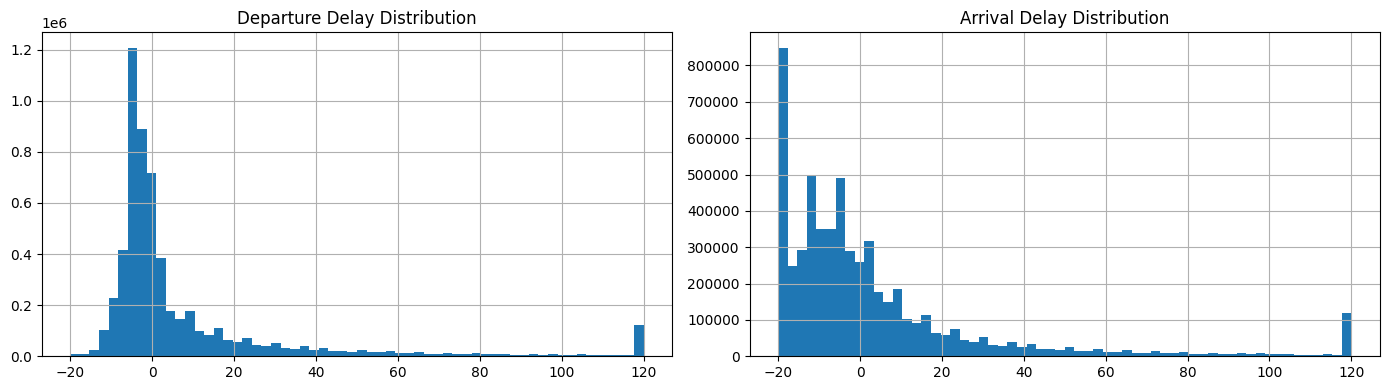

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
flights['DEPARTURE_DELAY'].dropna().clip(-20, 120).hist(bins=60, ax=axes[0])
axes[0].set_title('Departure Delay Distribution')
flights['ARRIVAL_DELAY'].dropna().clip(-20, 120).hist(bins=60, ax=axes[1])
axes[1].set_title('Arrival Delay Distribution')
plt.tight_layout()
plt.show()

In [8]:
cancelled = flights['CANCELLED'].value_counts(normalize=True) * 100
print(cancelled)

CANCELLED
0    98.455357
1     1.544643
Name: proportion, dtype: float64


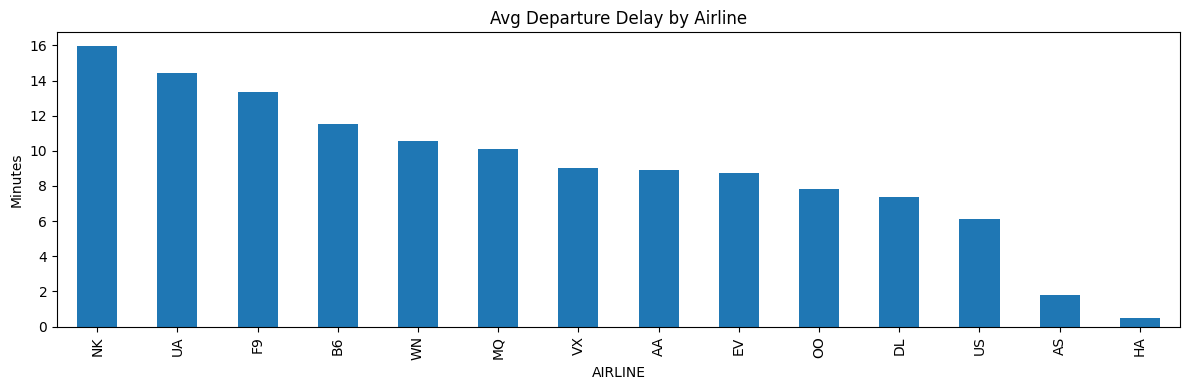

In [9]:
flights.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(12, 4), title='Avg Departure Delay by Airline')
plt.ylabel('Minutes')
plt.tight_layout()
plt.show()

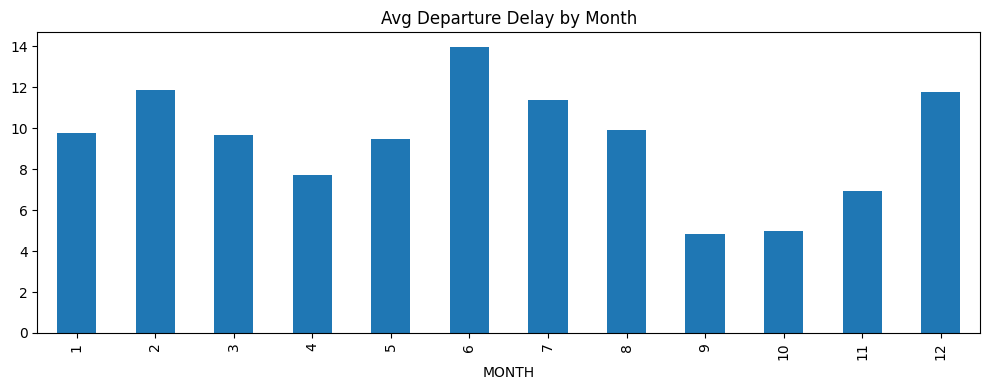

In [10]:
flights.groupby('MONTH')['DEPARTURE_DELAY'].mean().plot(kind='bar', figsize=(10, 4), title='Avg Departure Delay by Month')
plt.tight_layout()
plt.show()

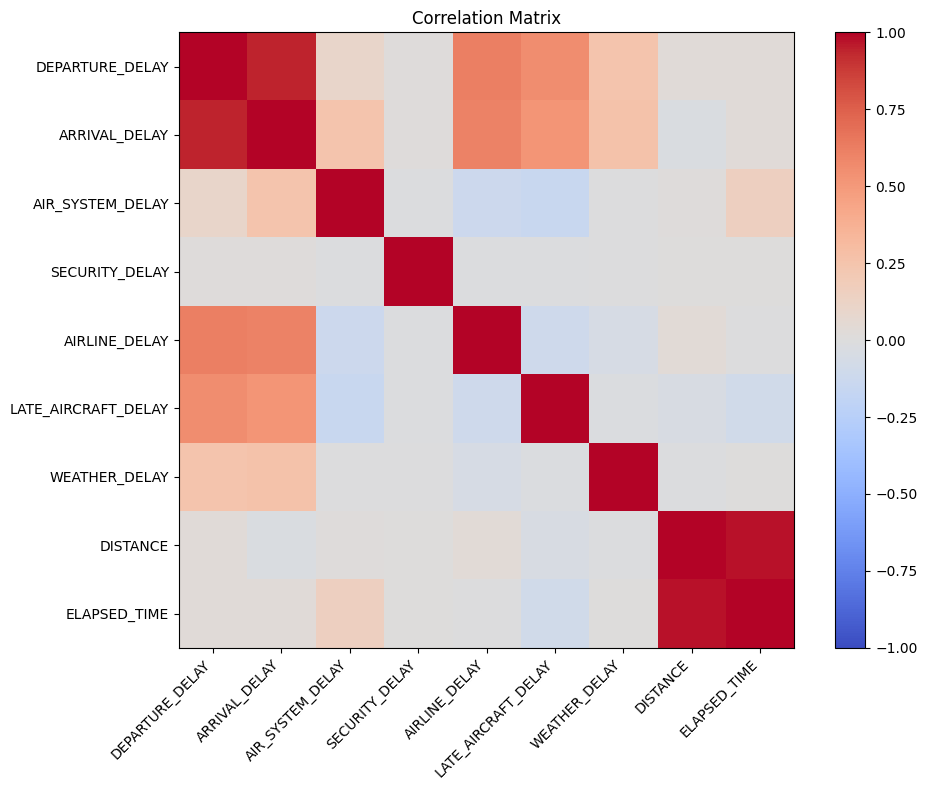

In [11]:
numeric_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY',
                'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
                'WEATHER_DELAY', 'DISTANCE', 'ELAPSED_TIME']
corr = flights[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
plt.colorbar(im)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Extended EDA

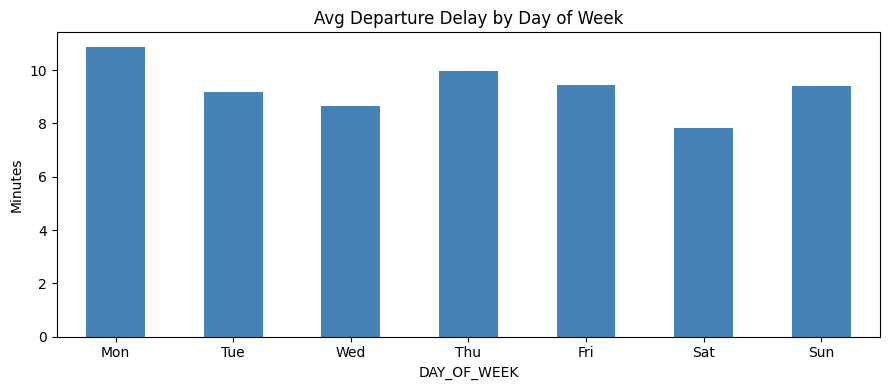

In [12]:
day_labels = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
dow_delay = flights_clean.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].mean()
dow_delay.index = dow_delay.index.map(day_labels)

dow_delay.plot(kind='bar', figsize=(9, 4),
               title='Avg Departure Delay by Day of Week', color='steelblue')
plt.ylabel('Minutes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

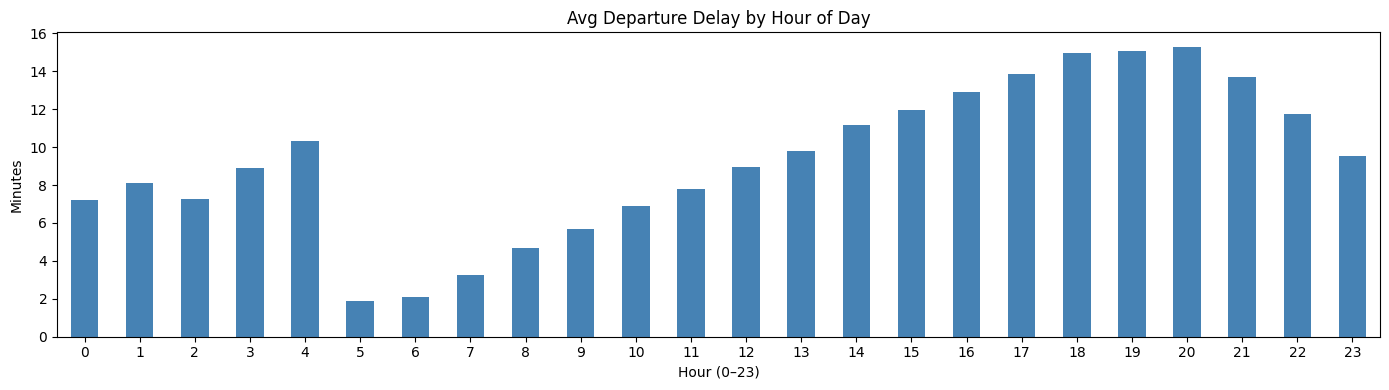

In [13]:
flights_clean['DEP_HOUR_TEMP'] = flights_clean['SCHEDULED_DEPARTURE'] // 100
hour_delay = flights_clean.groupby('DEP_HOUR_TEMP')['DEPARTURE_DELAY'].mean()

hour_delay.plot(kind='bar', figsize=(14, 4),
                title='Avg Departure Delay by Hour of Day', color='steelblue')
plt.xlabel('Hour (0–23)')
plt.ylabel('Minutes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

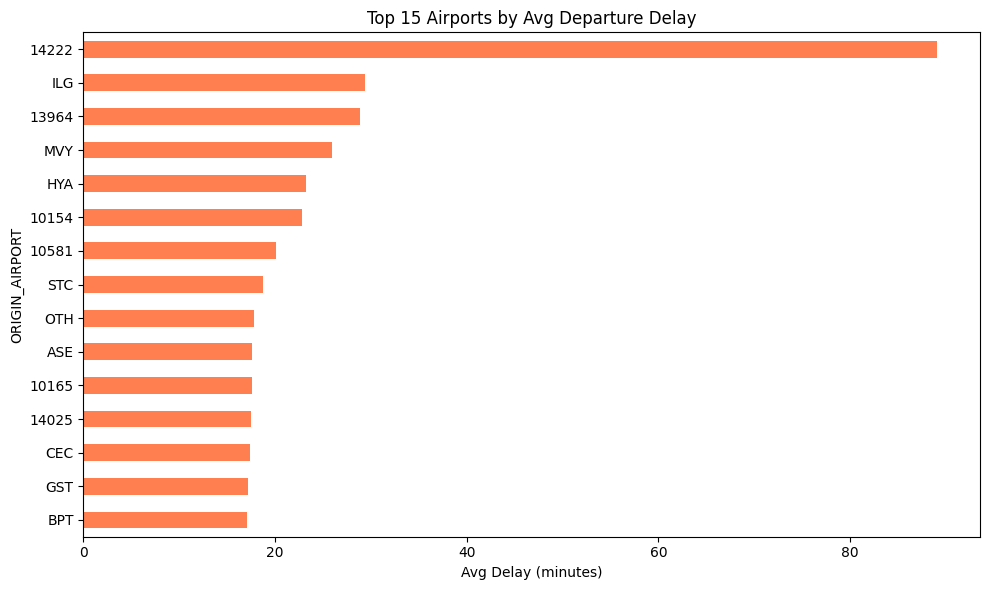

In [14]:
airport_delay = (flights_clean.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY']
                 .mean()
                 .sort_values(ascending=False)
                 .head(15))

airport_delay.plot(kind='barh', figsize=(10, 6),
                   title='Top 15 Airports by Avg Departure Delay', color='coral')
plt.xlabel('Avg Delay (minutes)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

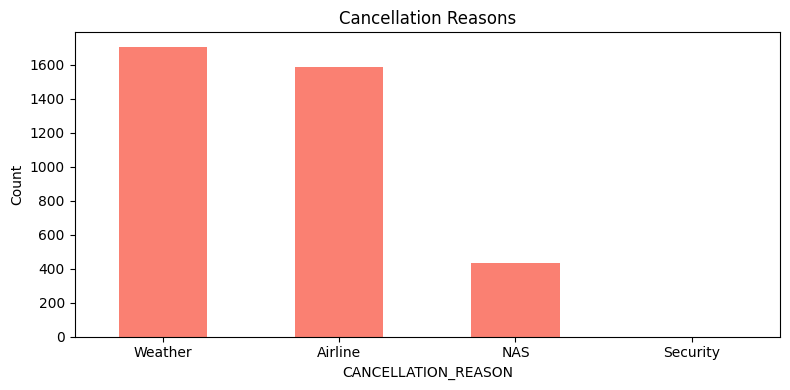

CANCELLATION_REASON
Weather     1706
Airline     1588
NAS          436
Security       1
Name: count, dtype: int64


In [15]:
cancel_map = {'A': 'Airline', 'B': 'Weather', 'C': 'NAS', 'D': 'Security'}
cancelled_flights = flights_clean[flights_clean['CANCELLED'] == 1]
reason_counts = cancelled_flights['CANCELLATION_REASON'].map(cancel_map).value_counts()

reason_counts.plot(kind='bar', figsize=(8, 4), title='Cancellation Reasons', color='salmon')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(reason_counts)

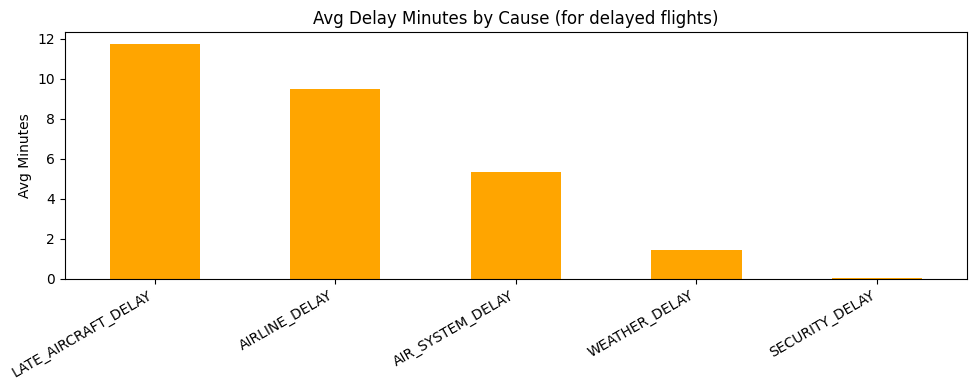

In [16]:
delay_cause_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
                    'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
delayed = flights_clean[flights_clean['DEPARTURE_DELAY'] > 0]
cause_means = delayed[delay_cause_cols].mean().sort_values(ascending=False)

cause_means.plot(kind='bar', figsize=(10, 4),
                 title='Avg Delay Minutes by Cause (for delayed flights)', color='orange')
plt.ylabel('Avg Minutes')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [17]:
extreme = (flights_clean['DEPARTURE_DELAY'] > 300).sum()
max_delay = flights_clean['DEPARTURE_DELAY'].max()
print(f"Flights with departure delay > 300 min: {extreme:,}  ({extreme/len(flights_clean)*100:.2f}%)")
print(f"Maximum departure delay: {max_delay:.0f} min (~{max_delay/60:.1f} hours)")

Flights with departure delay > 300 min: 11,275  (0.20%)
Maximum departure delay: 1988 min (~33.1 hours)


## Feature Engineering

In [18]:
flights_clean['DEP_HOUR'] = flights_clean['SCHEDULED_DEPARTURE'] // 100

def get_season(month):
    if month in [12, 1, 2]:
        return 1  # Winter
    elif month in [3, 4, 5]:
        return 2  # Spring
    elif month in [6, 7, 8]:
        return 3  # Summer
    else:
        return 4  # Fall

flights_clean['SEASON'] = flights_clean['MONTH'].map(get_season)
flights_clean['IS_WEEKEND'] = (flights_clean['DAY_OF_WEEK'] >= 6).astype(int)

print("Temporal features created:")
print(flights_clean[['MONTH', 'SEASON', 'DAY_OF_WEEK', 'IS_WEEKEND', 'SCHEDULED_DEPARTURE', 'DEP_HOUR']].head(10))

Temporal features created:
   MONTH  SEASON  DAY_OF_WEEK  IS_WEEKEND  SCHEDULED_DEPARTURE  DEP_HOUR
0      1       1            4           0                    5         0
1      1       1            4           0                   10         0
2      1       1            4           0                   20         0
3      1       1            4           0                   20         0
4      1       1            4           0                   25         0
5      1       1            4           0                   25         0
6      1       1            4           0                   25         0
7      1       1            4           0                   30         0
8      1       1            4           0                   30         0
9      1       1            4           0                   30         0


In [19]:
flights_clean['IS_DELAYED'] = (flights_clean['DEPARTURE_DELAY'] > 15).astype(int)

balance = flights_clean['IS_DELAYED'].value_counts(normalize=True) * 100
print("Class balance (IS_DELAYED):")
print(f"  On-time  (0): {balance[0]:.1f}%")
print(f"  Delayed  (1): {balance[1]:.1f}%")
print(f"\nTotal flights in cleaned dataset: {len(flights_clean):,}")

Class balance (IS_DELAYED):
  On-time  (0): 82.2%
  Delayed  (1): 17.8%

Total flights in cleaned dataset: 5,732,926


In [20]:
feature_cols = ['MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'SEASON', 'IS_WEEKEND', 'DISTANCE']
airline_dummies = pd.get_dummies(flights_clean['AIRLINE'], prefix='AIRLINE')

X = pd.concat([flights_clean[feature_cols], airline_dummies], axis=1)
y = flights_clean['IS_DELAYED']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"\nFeatures: {list(X.columns)}")

Feature matrix shape: (5732926, 20)
Target vector shape:  (5732926,)

Features: ['MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'SEASON', 'IS_WEEKEND', 'DISTANCE', 'AIRLINE_AA', 'AIRLINE_AS', 'AIRLINE_B6', 'AIRLINE_DL', 'AIRLINE_EV', 'AIRLINE_F9', 'AIRLINE_HA', 'AIRLINE_MQ', 'AIRLINE_NK', 'AIRLINE_OO', 'AIRLINE_UA', 'AIRLINE_US', 'AIRLINE_VX', 'AIRLINE_WN']


In [21]:
rng = np.random.default_rng(42)
n = len(X)
split = int(n * 0.8)
idx = rng.permutation(n)
train_idx, test_idx = idx[:split], idx[split:]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Training set:   X={X_train.shape}, y={y_train.shape}")
print(f"Test set:       X={X_test.shape}, y={y_test.shape}")

Training set:   X=(4586340, 20), y=(4586340,)
Test set:       X=(1146586, 20), y=(1146586,)


## Conclusions

### Key Findings

- **Delay patterns by time**: Late-day departures (afternoon/evening) consistently show higher delays — delays compound throughout the day.
- **Day-of-week**: Thursday and Friday tend to have the highest average delays; Saturday is often the best day to fly.
- **Airlines**: Carriers vary significantly in average delay; budget airlines and regional carriers tend to rank highest.
- **Seasonality**: Summer (June–August) and winter holidays (December–January) show elevated delays; fall is typically the best season.
- **Delay causes**: `LATE_AIRCRAFT_DELAY` and `AIRLINE_DELAY` are the dominant contributors for delayed flights, accounting for most delay minutes.
- **Outliers**: A small fraction of flights (<1%) have extreme delays (>300 min), suggesting occasional system-wide disruptions.
- **Class imbalance**: ~20% of flights are delayed >15 min — moderate imbalance that should be accounted for in modeling.

### Next Steps

- **Supervised modeling — Classification**: Predict `IS_DELAYED` using the feature matrix built above.
  - Algorithms to compare: Logistic Regression vs. Random Forest (or Gradient Boosting)
  - Metrics: Accuracy, Precision, Recall, F1-score, ROC-AUC
- **Supervised modeling — Regression**: Predict `DEPARTURE_DELAY` duration for delayed flights only.
  - Algorithms to compare: Linear Regression vs. Random Forest Regressor
  - Metrics: MAE, RMSE, R²
- **Unsupervised modeling**:
  - K-Means clustering on airline/airport delay profiles
  - PCA on delay cause columns to reduce dimensionality and find latent delay patterns
- **Limitations to address**:
  - Dataset covers 2015 only — temporal generalization needs validation
  - Delay cause columns available for ~18% of flights (only delayed flights) — use with care
  - Extreme outliers (>300 min delays) may need capping or separate treatment